# Overview & Goals



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from pathlib import Path

In [2]:
RAW_DIR = Path("../data/raw")

df_readiness = pd.read_csv(
    RAW_DIR / "readiness.csv",
    parse_dates=["day"]
)

df_hr = pd.read_csv(
    RAW_DIR / "heart_rate.csv",
    parse_dates=["timestamp"]
)

df_periods = pd.read_csv(
    RAW_DIR / "period_log.csv",
    parse_dates=["cycle_start_date"]
)

# print("Readiness:", df_readiness.shape, "| columns:", df_readiness.columns.tolist())
# print("Heart rate:", df_hr.shape, "| columns:", df_hr.columns.tolist())
# print("Periods:", df_periods.shape)
# print(df_periods)

In [11]:
# Sort period starts
period_starts = df_periods["cycle_start_date"].sort_values().reset_index(drop=True)

def get_cycle_day(date, period_starts):
    """Return (cycle_number, cycle_day) for a given date."""
    past_starts = period_starts[period_starts <= date]
    if len(past_starts) == 0:
        return None, None

    # cycle number = no. of cycles - 1 (0-based index)
    cycle_number = len(past_starts) - 1
    cycle_start = past_starts.iloc[-1]
    cycle_day = (date - cycle_start).days + 1
    return cycle_number, cycle_day


df_readiness["cycle_number"], df_readiness["cycle_day"] = zip(
    *df_readiness["day"].apply(lambda d: get_cycle_day(d, period_starts))
)

df_readiness = df_readiness.dropna(subset=["cycle_day"])
df_readiness["cycle_day"] = df_readiness["cycle_day"].astype(int)

print(df_readiness[["day", "cycle_day", "temperature_trend_deviation"]])

          day  cycle_day  temperature_trend_deviation
0  2026-03-05         24                          NaN
1  2026-03-06         25                         0.06
2  2026-03-07         26                         0.15
3  2026-03-08         27                         0.17
4  2026-03-09         28                         0.07
5  2026-03-10         29                         0.14
6  2026-03-11         30                        -0.03
7  2026-03-12          1                        -0.19
8  2026-03-13          2                        -0.05
9  2026-03-14          3                        -0.29
10 2026-03-15          4                        -0.23
11 2026-03-16          5                        -0.17
12 2026-03-17          6                        -0.13
13 2026-03-18          7                        -0.19
14 2026-03-19          8                        -0.15
15 2026-03-20          9                        -0.07
16 2026-03-21         10                        -0.17
17 2026-03-22         11    

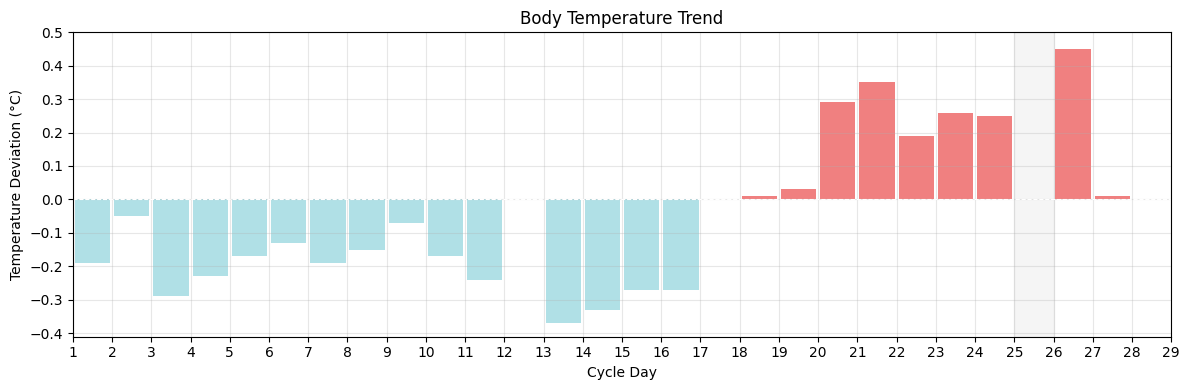

In [19]:
plt.style.use("seaborn-v0_8-muted")

latest_cycle = df_readiness["cycle_number"].max()-1
df_current = df_readiness[df_readiness["cycle_number"] == latest_cycle]

fig, ax = plt.subplots(figsize=(12, 4))

bar_width = 0.9

for day, val in zip(df_current["cycle_day"], df_current["temperature_trend_deviation"]):
    if pd.notna(val):
        color = "powderblue" if val < 0 else "lightcoral"
        ax.bar(day + 0.5, val, color=color, edgecolor="none", width=bar_width, align="center")
    else:
        ax.axvspan(day, day + 1, color="grey", alpha=0.08)

ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
ax.set_xlabel("Cycle Day")
ax.set_ylabel("Temperature Deviation (°C)")
ax.set_title("Body Temperature Trend")

max_day = df_current["cycle_day"].max()
min_day = df_current["cycle_day"].min()
ax.set_xticks(range(min_day, max_day + 2))
ax.set_xticklabels(range(min_day, max_day + 2))
ax.set_xlim(min_day, max_day + 1)

# y-axis ticks at 0.1C intervals
y_min = df_current["temperature_trend_deviation"].min(skipna=True)
y_max = df_current["temperature_trend_deviation"].max(skipna=True)
y_ticks = np.arange(np.floor(y_min * 10) / 10, np.ceil(y_max * 10) / 10 + 0.1, 0.1)
ax.set_yticks(np.round(y_ticks, 1))

ax.grid(axis="both", alpha=0.3)

plt.tight_layout()
plt.savefig("../assets/temperature_trend.png", dpi=150, bbox_inches="tight")
plt.show()